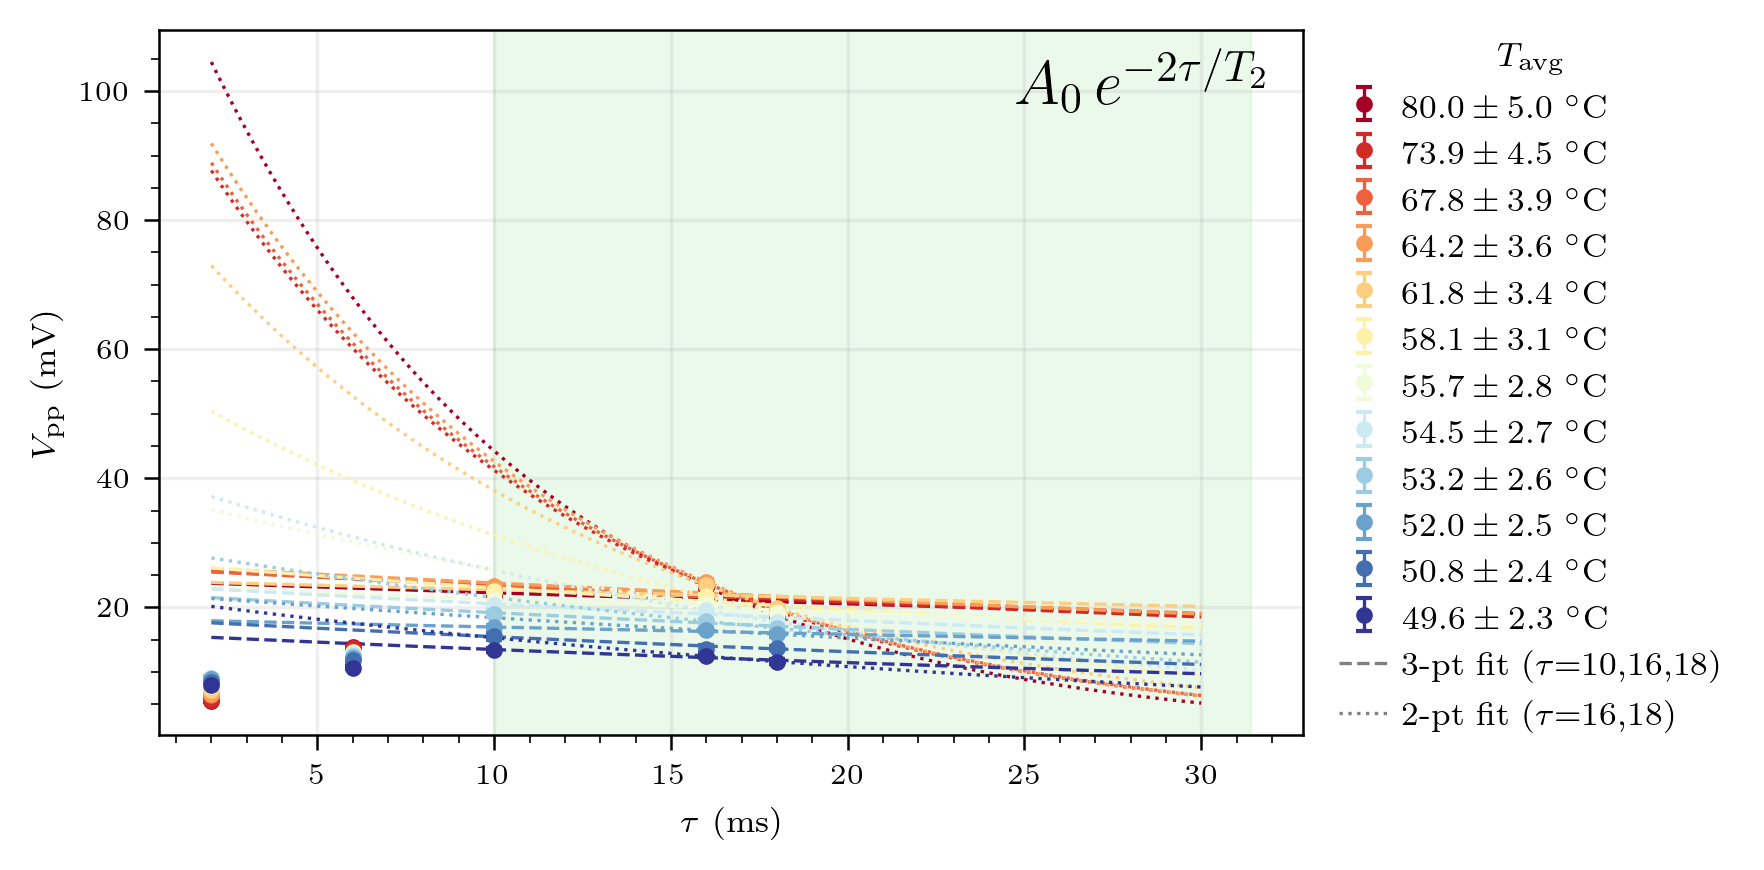

In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from scipy.optimize import curve_fit
from scipy.stats import chi2 as chi2_dist

plt.style.use('./jlab.mplstyle')

# --- Parse bwax_data_new.csv ---
df = pd.read_csv('bwax_data_new.csv', header=0)

tau_row      = df.iloc[0]
temp_df      = df.iloc[2:14]
calib_px_row = df.iloc[14]
calib_mV_row = df.iloc[15]

val_slice = slice(1, None, 2)
unc_slice = slice(2, None, 2)

temperatures = temp_df.iloc[:, 0].values.astype(float)
raw_px       = temp_df.iloc[:, val_slice].values.astype(float)
raw_unc      = temp_df.iloc[:, unc_slice].values.astype(float)

taus     = tau_row.iloc[val_slice].values.astype(float)
calib_px = calib_px_row.iloc[val_slice].values.astype(float)
calib_unc= calib_px_row.iloc[unc_slice].values.astype(float)
calib_mV = calib_mV_row.iloc[val_slice].values.astype(float)

# --- Linear temperature calibration ---
_slope = (80 - 23.8) / (70 - 23.8)
T_avg = _slope * (temperatures - 23.8) + 23.8
T_unc  = (5 / (70 - 23.8)) * (temperatures - 23.8)

# --- Load calibration cooling curves → timing uncertainty ---
cal_df = pd.read_csv('beeswax_temp_calibration.csv', header=None, skiprows=2,
                     names=['T', 't2', 'u2', 't6', 'u6', 't10', 'u10', 't16', 'u16', 't18', 'u18'])
cal_df['T'] = pd.to_numeric(cal_df['T'], errors='coerce')
cal_df = cal_df.dropna(subset=['T']).reset_index(drop=True)

t_cols = ['t2', 't6', 't10', 't16', 't18']
for col in t_cols:
    cal_df[col] = pd.to_numeric(cal_df[col], errors='coerce')

T_cal = cal_df['T'].values.astype(float)

dTdt_all = []
for col in t_cols:
    t_col = cal_df[col].values.astype(float)
    valid = ~np.isnan(t_col)
    T_valid = T_cal[valid]; t_valid = t_col[valid]
    dTdt_valid = np.gradient(T_valid, t_valid)
    idx_sort = np.argsort(T_valid)
    dTdt_interp = np.interp(temperatures, T_valid[idx_sort], dTdt_valid[idx_sort])
    dTdt_all.append(np.abs(dTdt_interp))

sigma_T_timing = np.mean(dTdt_all, axis=0) * 1.0
sigma_T_total  = np.sqrt(T_unc**2 + sigma_T_timing**2)

# --- Pixel → mV conversion ---
scale      = calib_mV / calib_px
amp_mV     = raw_px * scale[np.newaxis, :]
amp_unc_mV = amp_mV * np.sqrt((raw_unc / raw_px)**2 + (calib_unc / calib_px)**2)

# --- Fit setup ---
idx_16 = np.where(taus == 16)[0][0]
idx_18 = np.where(taus == 18)[0][0]

fit_mask_2pt = np.isin(taus, [16, 18])
fit_mask_3pt = np.isin(taus, [10, 16, 18])
taus_fit_2pt = taus[fit_mask_2pt]
taus_fit_3pt = taus[fit_mask_3pt]

# 2-pt fit valid only where amplitude is monotonically decreasing at τ=16,18
row_mask_2pt = amp_mV[:, idx_18] <= amp_mV[:, idx_16]
row_mask     = np.ones(len(temperatures), dtype=bool)   # all rows shown in table/plots

def exp_decay(tau, A0, T2):
    return A0 * np.exp(-2 * tau / T2)

T2_2pt      = np.full(len(temperatures), np.nan)
A0_2pt      = np.full(len(temperatures), np.nan)
T2_3pt      = np.full(len(temperatures), np.nan)
A0_3pt      = np.full(len(temperatures), np.nan)
T2_errs_3pt = np.full(len(temperatures), np.nan)
chi2_3pt    = np.full(len(temperatures), np.nan)

for i in range(len(temperatures)):
    # 2-point fit (τ=16,18) — only where monotone
    if row_mask_2pt[i]:
        y = amp_mV[i, fit_mask_2pt]; yerr = amp_unc_mV[i, fit_mask_2pt]
        p0 = [y[0] * np.exp(taus_fit_2pt[0] / 15), 15.0]
        popt, _ = curve_fit(exp_decay, taus_fit_2pt, y, p0=p0, sigma=yerr, absolute_sigma=True)
        A0_2pt[i] = popt[0]; T2_2pt[i] = popt[1]

    # 3-point fit (τ=10,16,18) — all rows
    y = amp_mV[i, fit_mask_3pt]; yerr = amp_unc_mV[i, fit_mask_3pt]
    p0 = [y[0] * np.exp(taus_fit_3pt[0] / 15), 15.0]
    popt, pcov = curve_fit(exp_decay, taus_fit_3pt, y, p0=p0, sigma=yerr, absolute_sigma=True)
    A0_3pt[i]      = popt[0]; T2_3pt[i] = popt[1]
    T2_errs_3pt[i] = np.sqrt(pcov[1, 1])
    residuals      = (y - exp_decay(taus_fit_3pt, *popt)) / yerr
    chi2_3pt[i]    = np.sum(residuals**2)

p_3pt   = chi2_dist.sf(chi2_3pt, df=1)
sys_err = T2_2pt - T2_3pt   # NaN where 2-pt invalid

# --- Plot 1: Amplitude vs tau — both fits overlaid ---
n      = len(temperatures)
colors = [cm.RdYlBu_r((n - 1 - i) / (n - 1)) for i in range(n)]
tau_fine = np.linspace(2, 30, 300)

fig, ax = plt.subplots(figsize=(6, 3))

for i, (T_a, T_s) in enumerate(zip(T_avg, sigma_T_total)):
    ax.errorbar(taus, amp_mV[i], yerr=amp_unc_mV[i],
                fmt='o', color=colors[i], capsize=2, lw=0.8, markersize=3,
                zorder=3, label=rf'${T_a:.1f} \pm {T_s:.1f}\ ^\circ$C')
    ax.plot(tau_fine, exp_decay(tau_fine, A0_3pt[i], T2_3pt[i]),
            color=colors[i], lw=0.8, ls='--', zorder=2)
    if row_mask_2pt[i]:
        ax.plot(tau_fine, exp_decay(tau_fine, A0_2pt[i], T2_2pt[i]),
                color=colors[i], lw=0.8, ls=':', zorder=2)

ax.axvspan(10, ax.get_xlim()[1], color='limegreen', alpha=0.1, zorder=1)

# Collect temperature legend handles, then append fit-style proxies
temp_handles, temp_labels = ax.get_legend_handles_labels()
style_handles = [
    Line2D([0], [0], color='gray', ls='--', lw=0.8, label=r'3-pt fit ($\tau$=10,16,18)'),
    Line2D([0], [0], color='gray', ls=':',  lw=0.8, label=r'2-pt fit ($\tau$=16,18)'),
]
ax.legend(handles=temp_handles + style_handles,
          bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8,
          handlelength=1.5, handletextpad=0.4, borderaxespad=0,
          title=r'$T_\mathrm{avg}$', title_fontsize=8)

ax.text(0.97, 0.97, r'$A_0\,e^{-2\tau/T_2}$', transform=ax.transAxes,
        ha='right', va='top', fontsize=15)

ax.set_xlabel(r'$\tau$ (ms)')
ax.set_ylabel(r'$V_\mathrm{pp}$ (mV)')
ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig('bwax_amplitude_vs_tau.png', dpi=300, bbox_inches='tight')
fig.savefig('bwax_amplitude_vs_tau.pdf', bbox_inches='tight')
plt.show()


In [97]:
table = pd.DataFrame({
    r'$T_\mathrm{avg}$ (°C)':            np.round(T_avg, 1),
    r'$\sigma_T$ (°C)':                  np.round(sigma_T_total, 2),
    r'$T_2^\mathrm{3pt}$ (ms)':          np.round(T2_3pt, 3),
    r'$\sigma_{T_2}$ (ms)':              np.round(T2_errs_3pt, 3),
    r'$T_2^\mathrm{2pt}$ (ms)':          np.round(T2_2pt, 3),
    r'$\Delta T_2^\mathrm{sys}$ (ms)':   np.round(sys_err, 3),
    r'$\chi^2$':                         np.round(chi2_3pt, 3),
    r'$p$':                              np.round(p_3pt, 3),
})
table.index = [''] * len(table)
display(table)


,$T_\mathrm{avg}$ (°C),$\sigma_T$ (°C),$T_2^\mathrm{3pt}$ (ms),$\sigma_{T_2}$ (ms),$T_2^\mathrm{2pt}$ (ms),$\Delta T_2^\mathrm{sys}$ (ms),$\chi^2$,$p$
,80.0,5.01,250.098,94.113,18.608,-231.490,54.667,0.000
,73.9,4.47,173.264,59.647,21.205,-152.058,39.772,0.000
,67.8,3.92,192.430,54.745,21.202,-171.228,39.718,0.000
,64.2,3.60,177.030,46.110,20.816,-156.215,40.752,0.000
,61.8,3.38,329.729,162.482,24.644,-305.085,31.679,0.000
,58.1,3.05,126.256,32.361,33.322,-92.934,10.759,0.001
,55.7,2.84,198.284,61.587,51.961,-146.323,4.114,0.043
,54.5,2.73,150.245,36.084,43.409,-106.837,5.217,0.022
,53.2,2.62,138.474,44.529,63.897,-74.577,1.342,0.247
,52.0,2.51,289.107,147.575,106.607,-182.500,0.588,0.443


In [98]:
import subprocess

# --- Error source summary table ---
T_avg_K = T_avg + 273.15

rel_T_cal    = (T_unc          / T_avg_K) * 100
rel_T_timing = (sigma_T_timing / T_avg_K) * 100
rel_T_total  = (sigma_T_total  / T_avg_K) * 100

valid_px  = (raw_px   > 0) & np.isfinite(raw_px)   & np.isfinite(raw_unc)
valid_cal = (calib_px > 0) & np.isfinite(calib_px) & np.isfinite(calib_unc)
rel_px      = (raw_unc[valid_px]    / raw_px[valid_px])    * 100
rel_cal_bar = (calib_unc[valid_cal] / calib_px[valid_cal]) * 100

rel_T2_stat = (T2_errs_3pt    / T2_3pt) * 100
rel_T2_sys  = (np.abs(sys_err) / T2_3pt) * 100

def _rng_str(arr):
    a = arr[np.isfinite(arr)]
    return '{:.3g}\u2013{:.3g}'.format(a.min(), a.max())

def _rng_latex(arr):
    a = arr[np.isfinite(arr)]
    return '{:.3g}--{:.3g}'.format(a.min(), a.max())

table_rows = [
    ('Camera calibration',       r'$T_\mathrm{avg}$', r'Linear rescaling; $\pm5\,^\circ$C uncertainty at reference point',       rel_T_cal),
    ('Timing delay',             r'$T_\mathrm{avg}$', r'1-s readout lag propagated via cooling rate $|dT/dt|$',                   rel_T_timing),
    ('Combined temperature',     r'$T_\mathrm{avg}$', r'Calibration + timing added in quadrature',                                rel_T_total),
    ('Pixel measurement',        r'$V_\mathrm{pp}$',  r'Manual pixel height reading of signal amplitude',                         rel_px),
    ('Calibration bar',          r'$V_\mathrm{pp}$',  r'Pixel uncertainty on mV scale bar; sets px\,$\to$\,mV conversion error',  rel_cal_bar),
    (r'$T_2$ fit (statistical)', r'$T_2$',            r'Curve-fit covariance from 3-pt ($\tau$=10,16,18\,ms) exponential fit',    rel_T2_stat),
    (r'$T_2$ fit (systematic)',  r'$T_2$',            r'Shift between 2-pt and 3-pt fit; sensitivity to $\tau$ point selection',  rel_T2_sys),
]

# --- Notebook display ---
err_table = pd.DataFrame(
    [(src, obs, desc, _rng_str(arr)) for src, obs, desc, arr in table_rows],
    columns=['Source', 'Observable', 'Description', 'Rel. range (%)'],
)
err_table.index = [''] * len(err_table)
display(err_table)

# --- Write error_summary.tex and compile ---
latex_rows = '\n'.join(
    r'  {} & {} & {} & {} \\ \hline'.format(src, obs, desc, _rng_latex(arr))
    for src, obs, desc, arr in table_rows
)

latex_doc = (
    r'\documentclass{article}' + '\n'
    r'\usepackage{amsmath}' + '\n'
    r'\usepackage{textcomp}' + '\n'
    r'\usepackage[margin=1in, landscape]{geometry}' + '\n'
    r'\begin{document}' + '\n\n'
    r'\begin{table}[h]' + '\n'
    r'\centering' + '\n'
    r'\caption{Error source summary}' + '\n'
    r'\begin{tabular}{|l|l|l|l|}' + '\n'
    r'\hline' + '\n'
    r'Source & Observable & Description & Rel.\ range (\%) \\ \hline' + '\n'
    + latex_rows + '\n'
    r'\end{tabular}' + '\n'
    r'\end{table}' + '\n\n'
    r'\end{document}' + '\n'
)

with open('error_summary.tex', 'w') as f:
    f.write(latex_doc)

result = subprocess.run(
    ['pdflatex', '-interaction=nonstopmode', 'error_summary.tex'],
    capture_output=True, text=True,
)
if result.returncode == 0:
    print('error_summary.pdf written successfully.')
else:
    print('pdflatex failed:')
    print(result.stdout[-3000:])


,Source,Observable,Description,Rel. range (%)
,Camera calibration,$T_\mathrm{avg}$,"Linear rescaling; $\pm5\,^\circ$C uncertainty ...",0.711–1.42
,Timing delay,$T_\mathrm{avg}$,1-s readout lag propagated via cooling rate $|...,0.00841–0.0985
,Combined temperature,$T_\mathrm{avg}$,Calibration + timing added in quadrature,0.711–1.42
,Pixel measurement,$V_\mathrm{pp}$,Manual pixel height reading of signal amplitude,0.814–3.85
,Calibration bar,$V_\mathrm{pp}$,"Pixel uncertainty on mV scale bar; sets px\,$\...",1.13–1.9
,$T_2$ fit (statistical),$T_2$,"Curve-fit covariance from 3-pt ($\tau$=10,16,1...",24–51
,$T_2$ fit (systematic),$T_2$,Shift between 2-pt and 3-pt fit; sensitivity t...,52.7–92.6


error_summary.pdf written successfully.


In [99]:
import subprocess

def _sf(x):
    return r'\textemdash' if np.isnan(x) else '{:.3g}'.format(x)

def _p(x):
    return r'\textemdash' if np.isnan(x) else '{:.2f}'.format(x)

rows = []
for T_a, s_T, T2_3, s_T2, T2_2, s_sys, chi2, p in zip(
        T_avg, sigma_T_total,
        T2_3pt, T2_errs_3pt,
        T2_2pt, sys_err,
        chi2_3pt, p_3pt):
    rows.append(
        r'  {} & {} & {} & {} & {} & {} & {} & {} \\ \hline'.format(
            _sf(T_a), _sf(s_T),
            _sf(T2_3), _sf(s_T2),
            _sf(T2_2), _sf(s_sys),
            _sf(chi2), _p(p)
        )
    )

table_body = '\n'.join(rows)

header = (
    r'$T_\mathrm{avg}$ (\textdegree C)'
    r' & $\sigma_T$ (\textdegree C)'
    r' & $T_2^\mathrm{3pt}$ (ms)'
    r' & $\sigma_{T_2}$ (ms)'
    r' & $T_2^\mathrm{2pt}$ (ms)'
    r' & $\Delta T_2^\mathrm{sys}$ (ms)'
    r' & $\chi^2$'
    r' & $p$ \\ \hline'
)

latex_doc = (
    r'\documentclass{article}' + '\n'
    r'\usepackage{amsmath}' + '\n'
    r'\usepackage{textcomp}' + '\n'
    r'\usepackage[margin=1in, landscape]{geometry}' + '\n'
    r'\begin{document}' + '\n\n'
    r'\begin{table}[h]' + '\n'
    r'\centering' + '\n'
    r'\caption{Beeswax $T_2$ fit results}' + '\n'
    r'\begin{tabular}{|r|r|r|r|r|r|r|r|}' + '\n'
    r'\hline' + '\n'
    + header + '\n'
    + table_body + '\n'
    r'\end{tabular}' + '\n'
    r'\end{table}' + '\n\n'
    r'\end{document}' + '\n'
)

with open('summary.tex', 'w') as f:
    f.write(latex_doc)

result = subprocess.run(
    ['pdflatex', '-interaction=nonstopmode', 'summary.tex'],
    capture_output=True, text=True,
)
if result.returncode == 0:
    print('summary.pdf written successfully.')
else:
    print('pdflatex failed:')
    print(result.stdout[-3000:])


summary.pdf written successfully.


The camera records temperature at discrete times, so a 1-second timing uncertainty $\Delta t = 1\ \text{s}$ propagates into a temperature uncertainty via

$$\sigma_T = \left|\frac{dT}{dt}\right| \Delta t$$

where $|dT/dt|$ is estimated from the calibration data. The derivative is approximated using central finite differences at interior points,

$$\left.\frac{dT}{dt}\right|_i = \frac{T_{i+1} - T_{i-1}}{t_{i+1} - t_{i-1}}$$

and one-sided differences at the endpoints. Since the calibration was repeated for each of the $N_\tau = 5$ pulse spacings $\tau$, the derivative estimates are interpolated to each measurement temperature and averaged across runs:

$$\sigma_T(T) = \Delta t \cdot \frac{1}{N_\tau} \sum_{k=1}^{N_\tau} \left|\frac{dT}{dt}\right|_k(T)$$

## Temperature Calibration

The thermal camera reads a raw temperature $T_\mathrm{cam}$. A two-point linear calibration corrects this to a true temperature $T_\mathrm{avg}$ using known reference points at $23.8\ ^\circ\mathrm{C}$ (ambient) and $70\ ^\circ\mathrm{C}$ (measured) corresponding to $80\ ^\circ\mathrm{C}$ (true):

$$T_\mathrm{avg} = \frac{80 - 23.8}{70 - 23.8}\left(T_\mathrm{cam} - 23.8\right) + 23.8$$

The calibration uncertainty propagates from a $\pm 5\ ^\circ\mathrm{C}$ uncertainty in the reference point, giving

$$\sigma_{T_\mathrm{avg}} = \frac{5}{70 - 23.8}\left(T_\mathrm{cam} - 23.8\right)$$

This uncertainty grows linearly with distance from the ambient reference point. The total $x$-uncertainty on $T_\mathrm{avg}$ is taken as $\sigma_T = \sqrt{\sigma_{T_\mathrm{avg}}^2 + \sigma_{\mathrm{timing}}^2}$, combining the calibration uncertainty with the 1-second timing uncertainty derived from the calibration cooling curves.


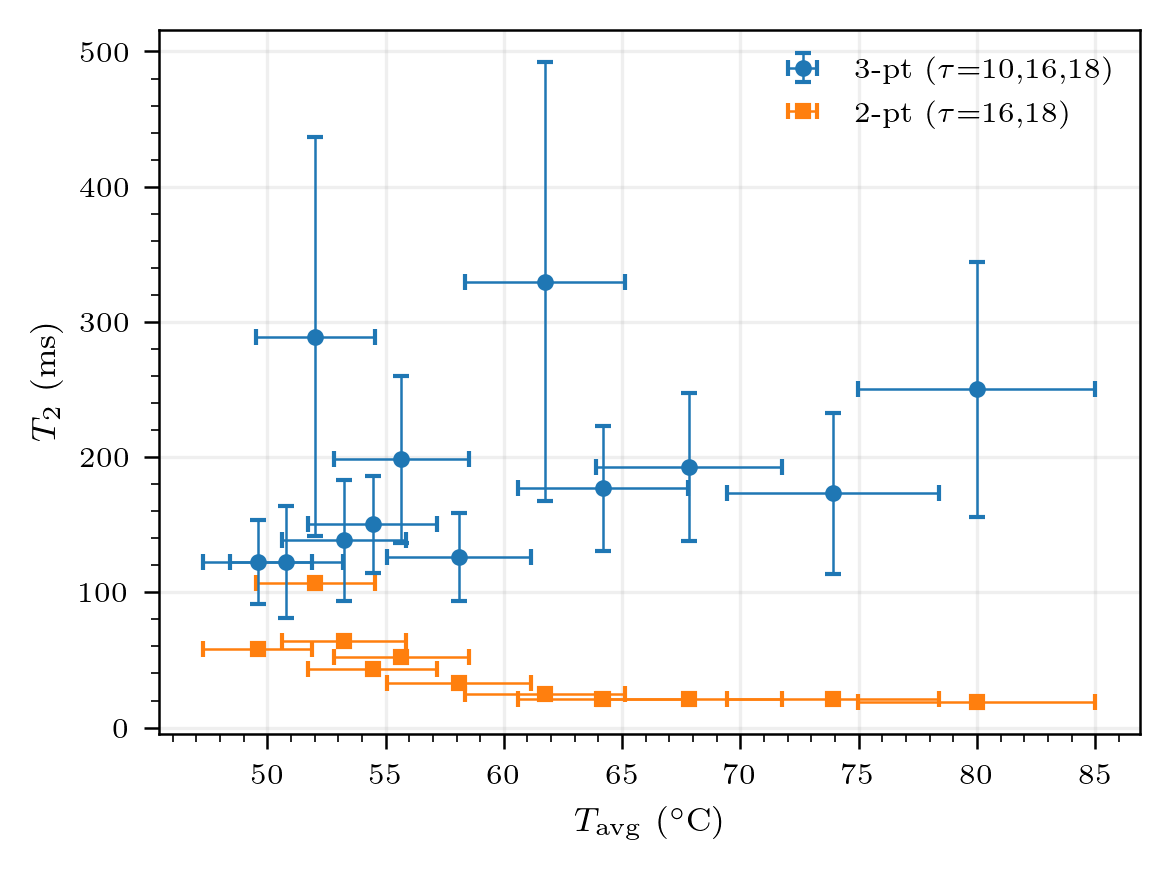

In [100]:
# --- Plot 2: T2 vs T_avg — both estimates ---
fig, ax = plt.subplots(figsize=(4, 3))

ax.errorbar(T_avg, T2_3pt, yerr=T2_errs_3pt, xerr=sigma_T_total,
            fmt='o', capsize=2, markersize=3, color='tab:blue',
            label=r'3-pt ($\tau$=10,16,18)', zorder=3)

ax.errorbar(T_avg[row_mask_2pt], T2_2pt[row_mask_2pt], xerr=sigma_T_total[row_mask_2pt],
            fmt='s', capsize=2, markersize=3, color='tab:orange',
            label=r'2-pt ($\tau$=16,18)', zorder=2)

ax.legend(fontsize=7)
ax.set_xlabel(r'$T_\mathrm{avg}$ ($^\circ$C)')
ax.set_ylabel(r'$T_2$ (ms)')
ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig('bwax_T2_vs_Tcam.png', dpi=300, bbox_inches='tight')
fig.savefig('bwax_T2_vs_Tcam.pdf', bbox_inches='tight')
plt.show()


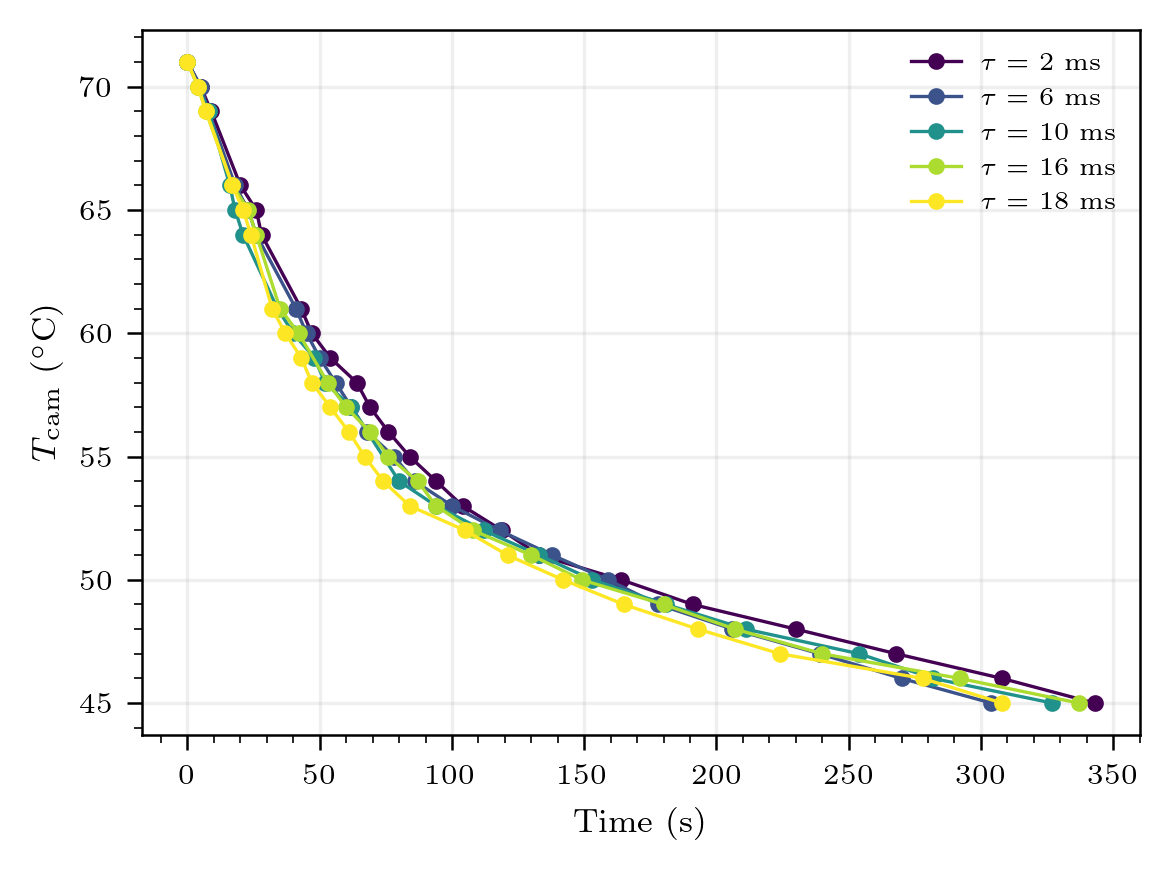

In [101]:
# --- Plot: T_cam vs time for each tau ---
tau_labels = [2, 6, 10, 16, 18]
tau_t_cols  = ['t2', 't6', 't10', 't16', 't18']

norm_tau = mcolors.Normalize(vmin=min(tau_labels), vmax=max(tau_labels))
cmap_tau = cm.viridis

fig, ax = plt.subplots(figsize=(4, 3))

for tau, col in zip(tau_labels, tau_t_cols):
    t_col = cal_df[col].values.astype(float)
    valid = ~np.isnan(t_col)
    t_zeroed = t_col[valid] - t_col[valid].min()
    color = cmap_tau(norm_tau(tau))
    ax.plot(t_zeroed, T_cal[valid], 'o-', color=color,
            lw=0.8, markersize=3, label=rf'$\tau={tau}$ ms')

ax.set_xlabel(r'Time (s)')
ax.set_ylabel(r'$T_\mathrm{cam}$ ($^\circ$C)')
ax.legend(fontsize=6, loc='upper right')
ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig('bwax_Tcam_vs_time.png', dpi=300, bbox_inches='tight')
fig.savefig('bwax_Tcam_vs_time.pdf', bbox_inches='tight')
plt.show()
